# Vietnamese Handwriting OCR - Kaggle Realtime Runtime

Notebook nay viet lai `ocr-train-chuan.ipynb` theo huong **inference-first**:

- giu checkpoint baseline sach hien tai
- toi uu line OCR cho realtime va fallback nhe
- ho tro `line -> sentence -> page -> paragraph`
- benchmark truc tiep `quality_2304` va `adaptive_realtime`
- export artifact dung ngay tren Kaggle

Notebook nay **khong fine-tune**, **khong resume train**, va **khong dung token-corrector** tren duong suy luan mac dinh.


In [1]:
import os
import sys
import re
import io
import csv
import math
import time
import json
import shutil
import zipfile
import hashlib
import random
import string
import warnings
import pkgutil
import subprocess
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

def ensure_package(package_name: str, import_name: str | None = None) -> None:
    import_name = import_name or package_name
    if pkgutil.find_loader(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

ensure_package("editdistance")
ensure_package("scikit-learn", "sklearn")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import editdistance
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras import mixed_precision
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

try:
    tf.config.optimizer.set_experimental_options({"layout_optimizer": False})
except Exception as exc:
    print("layout_optimizer config skipped:", exc)

if gpus:
    mixed_precision.set_global_policy("mixed_float16")

strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()

print("TensorFlow:", tf.__version__)
print("GPUs      :", len(gpus))
print("Strategy  :", type(strategy).__name__)
print("Policy    :", mixed_precision.global_policy())


2026-03-22 13:50:13.421812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774187413.611795      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774187413.665276      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774187414.151443      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774187414.151484      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774187414.151486      24 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow: 2.19.0
GPUs      : 2
Strategy  : MirroredStrategy
Policy    : <DTypePolicy "mixed_float16">


I0000 00:00:1774187437.625428      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774187437.631353      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
CFG = {
    "run_mode": "runtime_realtime",
    "target_height": 96,
    "downsample_factor": 4,
    "per_device_batch_size": 2,
    "val_size": 0.12,
    "max_width": 2304,
    "min_width": 64,
    "width_pad_multiple": 16,
    "fixed_eval_width": 2304,
    "preprocess_profiles": ["legacy_clean"],
    "mode": "adaptive_realtime",  # "quality_2304" | "adaptive_realtime"
    "quality_width": 2304,
    "width_buckets": [1024, 1536, 1792, 2304],
    "fallback_confidence_threshold": 0.97,
    "enable_fallback_rerun": True,
    "adaptive_near_ceiling_margin": 32,
    "adaptive_max_cer_delta": 0.0015,
    "adaptive_max_exact_drop": 0.0030,
    "adaptive_min_throughput_gain": 0.15,
    "dataset_root": None,
    "weights_path": "/kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5",
    "resume_artifact": None,
    "camera_hard_eval_root": None,
    "camera_hard_sample_size": 256,
    "camera_hard_enabled": True,
    "preview_samples": 4,
    "page_demo_enabled": True,
    "page_demo_root": None,
    "page_demo_pages": 3,
    "page_demo_lines_per_page": 4,
    "page_demo_seed": SEED,
    "page_crop_margin": 16,
    "page_deskew_clamp_degrees": 8.0,
    "page_segment_kernel_width": 35,
    "page_segment_kernel_height": 3,
    "page_segment_min_width": 40,
    "page_segment_min_height": 12,
    "page_segment_merge_gap": 14,
    "page_paragraph_gap_ratio": 1.6,
    "line_demo_samples": 40,
    "single_line_latency_samples": 24,
    "export_runtime_bundle": True,
    "output_root": "/kaggle/working/ocr_runtime_realtime_run",
}

CFG["global_batch_size"] = CFG["per_device_batch_size"] * strategy.num_replicas_in_sync
OUTPUT_ROOT = Path(CFG["output_root"])
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

PATHS = {
    "metadata_cache": OUTPUT_ROOT / "ocr_metadata_cache.csv",
    "config_json": OUTPUT_ROOT / "run_config.json",
    "runtime_profile_json": OUTPUT_ROOT / "runtime_profile.json",
    "benchmark_compare_csv": OUTPUT_ROOT / "benchmark_compare.csv",
    "line_demo_csv": OUTPUT_ROOT / "line_demo_predictions.csv",
    "page_demo_json": OUTPUT_ROOT / "page_demo_results.json",
    "export_model": OUTPUT_ROOT / "ocr_inference.keras",
    "bundle_zip": OUTPUT_ROOT / "artifact_bundle.zip",
    "metrics_dir": OUTPUT_ROOT / "metrics",
    "predictions_dir": OUTPUT_ROOT / "predictions",
    "page_overlay_dir": OUTPUT_ROOT / "page_demo_overlays",
    "page_synth_dir": OUTPUT_ROOT / "page_demo_sources",
}

PATHS["metrics_dir"].mkdir(parents=True, exist_ok=True)
PATHS["predictions_dir"].mkdir(parents=True, exist_ok=True)
PATHS["page_overlay_dir"].mkdir(parents=True, exist_ok=True)
PATHS["page_synth_dir"].mkdir(parents=True, exist_ok=True)

with open(PATHS["config_json"], "w", encoding="utf-8") as f:
    json.dump(CFG, f, ensure_ascii=False, indent=2)

print(json.dumps(CFG, ensure_ascii=False, indent=2))


{
  "run_mode": "runtime_realtime",
  "target_height": 96,
  "downsample_factor": 4,
  "per_device_batch_size": 2,
  "val_size": 0.12,
  "max_width": 2304,
  "min_width": 64,
  "width_pad_multiple": 16,
  "fixed_eval_width": 2304,
  "preprocess_profiles": [
    "legacy_clean"
  ],
  "mode": "adaptive_realtime",
  "quality_width": 2304,
  "width_buckets": [
    1024,
    1536,
    1792,
    2304
  ],
  "fallback_confidence_threshold": 0.97,
  "enable_fallback_rerun": true,
  "adaptive_near_ceiling_margin": 32,
  "adaptive_max_cer_delta": 0.0015,
  "adaptive_max_exact_drop": 0.003,
  "adaptive_min_throughput_gain": 0.15,
  "dataset_root": null,
  "weights_path": "/kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5",
  "resume_artifact": null,
  "camera_hard_eval_root": null,
  "camera_hard_sample_size": 256,
  "camera_hard_enabled": true,
  "preview_samples": 4,
  "page_demo_enabled": true,
  "page_demo_root": n

In [3]:
SEARCH_ROOTS = [Path("/kaggle/input"), Path("/kaggle/working"), Path.cwd()]


def existing_search_roots():
    return [root for root in SEARCH_ROOTS if root.exists()]


def discover_dataset_root(manual_path=None):
    if manual_path:
        root = Path(manual_path)
        if (root / "labels.json").exists() and (root / "data").exists():
            return root
        raise FileNotFoundError(f"Dataset root khong hop le: {root}")

    candidates = []
    for root in existing_search_roots():
        for labels_path in root.rglob("labels.json"):
            dataset_root = labels_path.parent
            if (dataset_root / "data").exists():
                score = 0
                lower = str(dataset_root).lower()
                if "vn_handwritten_images" in lower:
                    score += 5
                if "hand" in lower or "written" in lower:
                    score += 2
                candidates.append((score, str(dataset_root), dataset_root))
    if not candidates:
        raise FileNotFoundError("Khong tim thay dataset co labels.json va data/")
    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][2]


def discover_weights(manual_path=None):
    if manual_path:
        p = Path(manual_path)
        if p.exists():
            return p
        raise FileNotFoundError(f"Khong tim thay weights: {p}")

    preferred = {
        "ocr-train-chuan_checkpoint.weights.h5": 8,
        "best.weights.h5": 6,
        "latest.weights.h5": 5,
    }
    candidates = []
    for root in existing_search_roots():
        for path in root.rglob("*.h5"):
            if not path.is_file():
                continue
            score = preferred.get(path.name, 0)
            low = path.name.lower()
            if "checkpoint" in low:
                score += 2
            if "best" in low:
                score += 1
            if "ocr" in low:
                score += 1
            candidates.append((score, str(path), path))
    if not candidates:
        return None
    candidates.sort(key=lambda x: (-x[0], x[1]))
    return candidates[0][2]


def discover_camera_hard_root(manual_path=None):
    if manual_path:
        root = Path(manual_path)
        if (root / "labels.json").exists() and (root / "data").exists():
            return root
        raise FileNotFoundError(f"camera_hard_eval_root khong hop le: {root}")
    return None


DATASET_ROOT = discover_dataset_root(CFG["dataset_root"])
LABELS_PATH = DATASET_ROOT / "labels.json"
IMAGE_DIR = DATASET_ROOT / "data"
WEIGHTS_PATH = discover_weights(CFG["weights_path"])
CAMERA_HARD_ROOT = discover_camera_hard_root(CFG["camera_hard_eval_root"])

print("DATASET_ROOT     =", DATASET_ROOT)
print("WEIGHTS_PATH     =", WEIGHTS_PATH)
print("CAMERA_HARD_ROOT =", CAMERA_HARD_ROOT)


DATASET_ROOT     = /kaggle/input/datasets/huyyuh/3500-w/vn_handwritten_images
WEIGHTS_PATH     = /kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5
CAMERA_HARD_ROOT = None


In [4]:
with open(LABELS_PATH, "r", encoding="utf-8") as f:
    raw_labels = json.load(f)

def build_legacy_charset():
    vietnamese_vowels = [
        "a","à","á","ả","ã","ạ","ă","ằ","ắ","ẳ","ẵ","ặ","â","ầ","ấ","ẩ","ẫ","ậ",
        "e","è","é","ẻ","ẽ","ẹ","ê","ề","ế","ể","ễ","ệ",
        "i","ì","í","ỉ","ĩ","ị",
        "o","ò","ó","ỏ","õ","ọ","ô","ồ","ố","ổ","ỗ","ộ","ơ","ờ","ớ","ở","ỡ","ợ",
        "u","ù","ú","ủ","ũ","ụ","ư","ừ","ứ","ử","ữ","ự",
        "y","ỳ","ý","ỷ","ỹ","ỵ"
    ]
    vietnamese_consonants = ["b","c","d","đ","g","h","k","l","m","n","p","q","r","s","t","v","x"]
    upper_vowels = [c.upper() for c in vietnamese_vowels]
    upper_consonants = [c.upper() for c in vietnamese_consonants]
    digits = list("0123456789")
    punctuation = [" ", ".", ",", ":", ";", "!", "?", "-", "_", "(", ")", "[", "]", "/", "%", "&", "*", "=", "@", "$", "'", "\""]
    extra_chars = ["f", "j", "w", "z", "F", "J", "W", "Z", "#", "+"]
    return sorted(set(vietnamese_vowels + vietnamese_consonants + upper_vowels + upper_consonants + digits + punctuation + extra_chars))

char_list = build_legacy_charset()
char_to_idx = {c: i for i, c in enumerate(char_list)}
idx_to_char = {i: c for i, c in enumerate(char_list)}

dataset_chars = sorted(set("".join(raw_labels.values())))
missing_chars = sorted(set(dataset_chars) - set(char_list))
if missing_chars:
    raise ValueError(f"Dataset co ky tu ngoai legacy charset: {missing_chars[:20]}")

def encode_text(text: str):
    return [char_to_idx[c] for c in text if c in char_to_idx]

def build_source_group(filename: str) -> str:
    stem = Path(filename).stem
    if stem.endswith("_samples"):
        return f"samples:{stem.replace('_samples', '')}"
    if "_" in stem:
        first = stem.split("_")[0]
        if first.isdigit():
            return f"crop:{first}"
    if stem.isdigit():
        return f"single:{stem}"
    return f"misc:{stem}"

cache_path = PATHS["metadata_cache"]
use_cache = False
if cache_path.exists():
    cached = pd.read_csv(cache_path)
    if not cached.empty and "dataset_root" in cached.columns and str(cached["dataset_root"].iloc[0]) == str(DATASET_ROOT):
        records_df = cached.copy()
        use_cache = True

if not use_cache:
    rows = []
    for filename, text in raw_labels.items():
        image_path = IMAGE_DIR / filename
        if not image_path.exists():
            continue
        try:
            with Image.open(image_path) as img:
                width, height = img.size
        except Exception:
            continue
        scaled_width = int(round(width * CFG["target_height"] / max(1, height)))
        scaled_width = max(CFG["min_width"], min(CFG["max_width"], scaled_width))
        rows.append(
            {
                "dataset_root": str(DATASET_ROOT),
                "filename": filename,
                "path": str(image_path),
                "text": text,
                "label_length": len(text),
                "orig_width": width,
                "orig_height": height,
                "scaled_width": scaled_width,
                "source_group": build_source_group(filename),
            }
        )
    records_df = pd.DataFrame(rows)
    records_df.to_csv(cache_path, index=False, encoding="utf-8-sig")

records_df["required_width"] = (records_df["label_length"] + 2) * CFG["downsample_factor"]
records_df["encoded"] = records_df["text"].apply(encode_text)
records_df["encoded_length"] = records_df["encoded"].apply(len)
records_df["final_width_hint"] = records_df[["scaled_width", "required_width"]].max(axis=1)
records_df["length_bin"] = pd.cut(
    records_df["label_length"],
    bins=[-1, 10, 25, 50, 75, 100, 1000],
    labels=["<=10", "11-25", "26-50", "51-75", "76-100", ">100"],
)

splitter = GroupShuffleSplit(n_splits=1, test_size=CFG["val_size"], random_state=SEED)
train_idx, val_idx = next(splitter.split(records_df, groups=records_df["source_group"]))
train_df = records_df.iloc[train_idx].reset_index(drop=True)
val_df = records_df.iloc[val_idx].reset_index(drop=True)

print("All samples :", len(records_df))
print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))
print("Unique train groups:", train_df["source_group"].nunique())
print("Unique val groups  :", val_df["source_group"].nunique())

group_overlap = set(train_df["source_group"]) & set(val_df["source_group"])
print("Shared groups:", len(group_overlap))

display(records_df.head(3))
display(pd.concat(
    [
        train_df["length_bin"].value_counts(normalize=True).rename("train_ratio"),
        val_df["length_bin"].value_counts(normalize=True).rename("val_ratio"),
    ],
    axis=1,
).fillna(0.0))


All samples : 15267
Train samples: 13944
Val samples  : 1323
Unique train groups: 2231
Unique val groups  : 305
Shared groups: 0


,dataset_root,filename,path,text,label_length,orig_width,orig_height,scaled_width,source_group,required_width,encoded,encoded_length,final_width_hint,length_bin
0,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,1.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"Số 3 Nguyễn Ngọc Vũ, Hà Nội",27,1684,245,660,single:1,116,"[49, 179, 0, 19, 0, 44, 66, 80, 84, 167, 73, 0...",27,660,26-50
1,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,2.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"Số 30 Nguyên Hồng, Láng Hạ, Đống Đa, Hà Nội",43,2030,276,706,single:2,180,"[49, 179, 0, 19, 16, 0, 44, 66, 80, 84, 108, 7...",43,706,26-50
2,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,3.jpg,/kaggle/input/datasets/huyyuh/3500-w/vn_handwr...,"58 Thái Thịnh, Đống Đa, Hà Nội",30,2544,376,650,single:3,128,"[21, 24, 0, 50, 67, 103, 68, 0, 50, 67, 173, 7...",30,650,26-50


,train_ratio,val_ratio
length_bin,,
51-75,0.358003,0.363568
<=10,0.233362,0.288738
26-50,0.203385,0.201814
76-100,0.164730,0.117158
11-25,0.036862,0.027967
>100,0.003657,0.000756


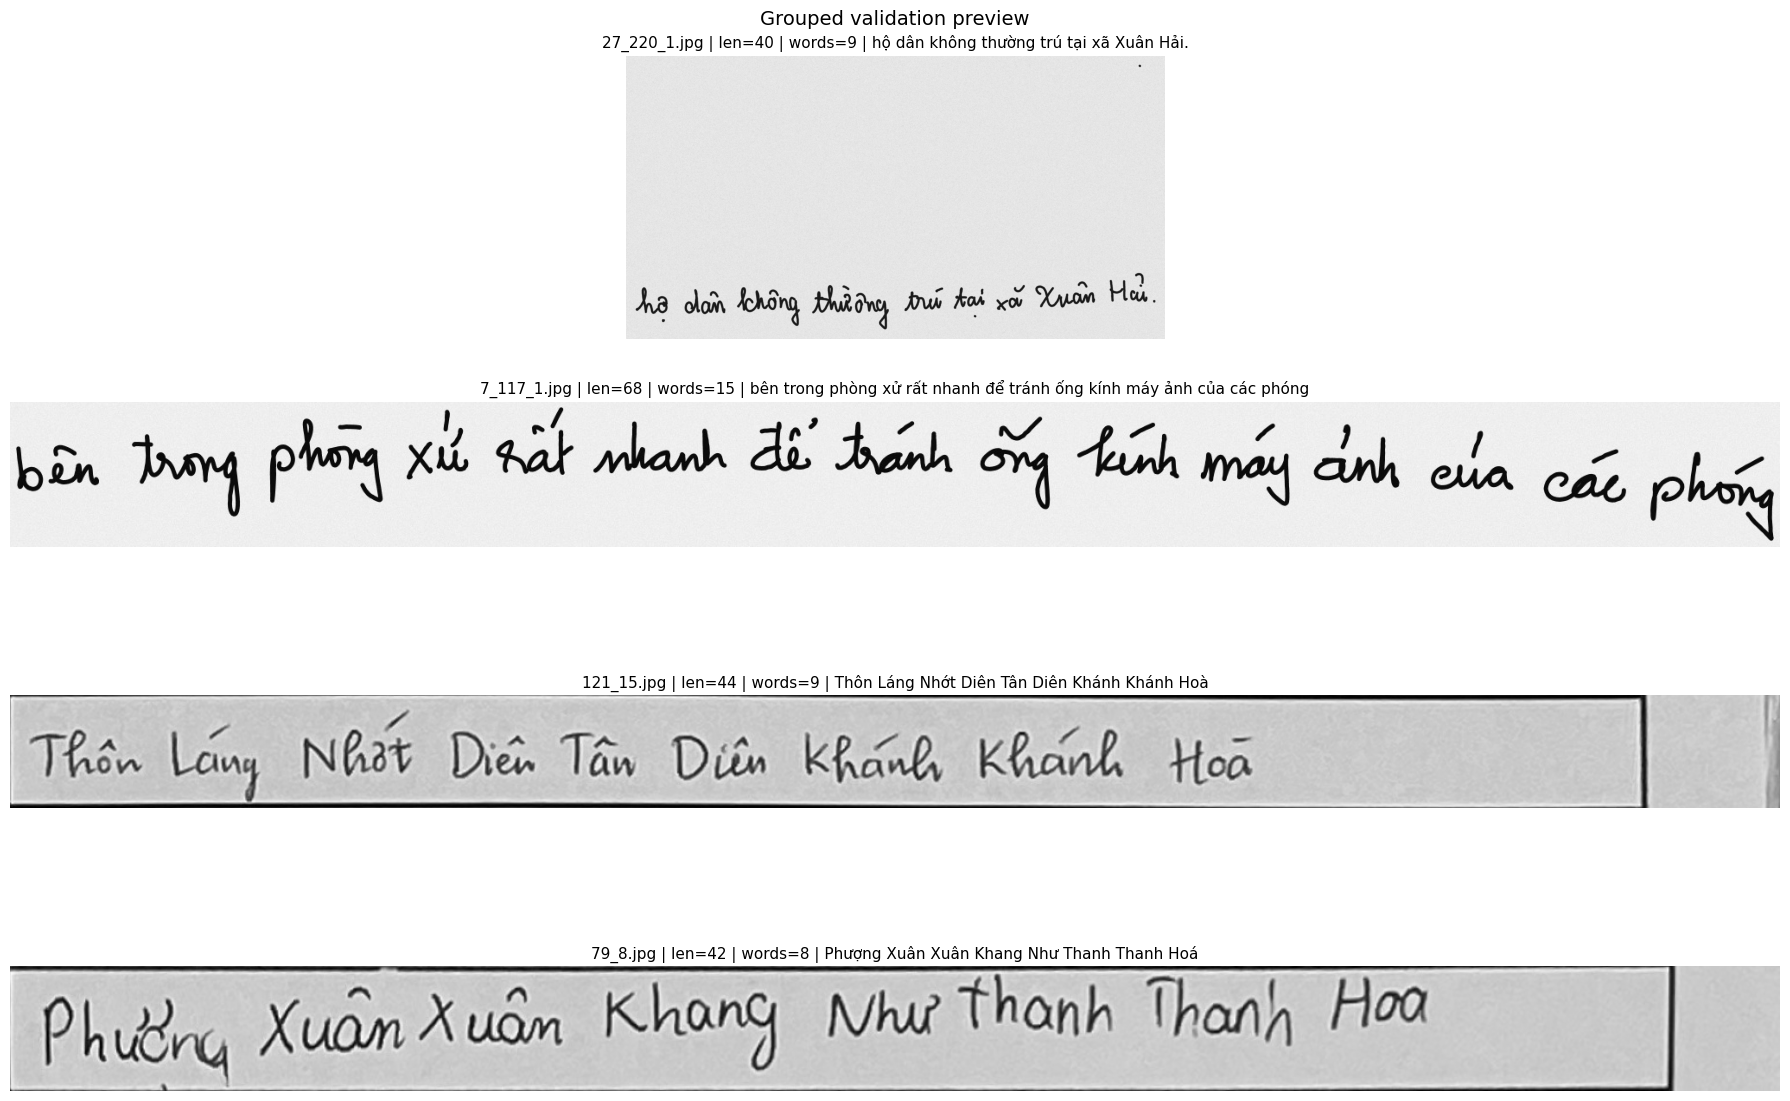

In [5]:
def show_dataset_samples(df, title, n=6, seed=SEED):
    sample_df = df.sample(min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample_df), 1, figsize=(18, 3 * len(sample_df)))
    if len(sample_df) == 1:
        axes = [axes]
    for ax, row in zip(axes, sample_df.itertuples()):
        img = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap="gray")
        word_count = int(getattr(row, "word_count", len(re.findall(r"\w+", str(row.text), re.UNICODE))))
        ax.set_title(f"{row.filename} | len={row.label_length} | words={word_count} | {row.text}", fontsize=11)
        ax.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_dataset_samples(val_df, "Grouped validation preview", n=CFG["preview_samples"])


## Runtime preprocess va page pipeline

- giu `legacy_clean` de tuong thich checkpoint cu
- `quality_2304`: width co dinh 2304, uu tien accuracy
- `adaptive_realtime`: chon bucket nho nhat trong `[1024, 1536, 1792, 2304]`, co 1 lan fallback neu confidence thap
- page mode gia dinh giay trang mot cot, deskew nhe, tach dong bang contour + projection


In [6]:
def stable_int_seed(text: str) -> int:
    return int(hashlib.md5(text.encode("utf-8")).hexdigest()[:8], 16)

def align_width(width: int, multiple: int) -> int:
    return int(math.ceil(width / multiple) * multiple)

def add_shadow(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    x = np.linspace(0, 1, w, dtype=np.float32)
    y = np.linspace(0, 1, h, dtype=np.float32)
    xv, yv = np.meshgrid(x, y)
    mask = xv if rng.random() < 0.5 else yv
    if rng.random() < 0.5:
        mask = 1.0 - mask
    strength = rng.uniform(0.20, 0.65) if hard else rng.uniform(0.35, 0.75)
    shadow = strength + (1.0 - strength) * mask
    out = gray.astype(np.float32) * shadow
    return np.clip(out, 0, 255).astype(np.uint8)

def add_glare(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    canvas = gray.astype(np.float32).copy()
    for _ in range(1 if not hard else 2):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        radius = int(rng.integers(max(20, w // 10), max(30, w // 4)))
        overlay = np.zeros_like(canvas)
        cv2.circle(overlay, center, radius, 255, -1)
        alpha = rng.uniform(0.08, 0.18) if not hard else rng.uniform(0.15, 0.28)
        canvas = cv2.addWeighted(canvas, 1.0, overlay, alpha, 0.0)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def add_stains(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    canvas = gray.astype(np.float32).copy()
    h, w = gray.shape
    num_blobs = int(rng.integers(3, 8 if not hard else 12))
    for _ in range(num_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(8, w // 40), max(12, w // (8 if hard else 10)))),
            int(rng.integers(max(6, h // 8), max(8, h // (2 if hard else 3)))),
        )
        color = float(rng.integers(150 if hard else 170, 255))
        angle = float(rng.integers(0, 180))
        cv2.ellipse(canvas, center, axes, angle, 0, 360, color, -1)
    alpha = 0.18 if hard else 0.12
    mixed = cv2.addWeighted(gray.astype(np.float32), 1.0 - alpha, canvas, alpha, 0)
    return np.clip(mixed, 0, 255).astype(np.uint8)

def add_occlusion(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    out = gray.copy()
    h, w = out.shape
    num_boxes = int(rng.integers(1, 2 if not hard else 4))
    for _ in range(num_boxes):
        bw = int(rng.integers(max(12, w // 30), max(20, w // (8 if hard else 12))))
        bh = int(rng.integers(max(4, h // 12), max(6, h // (4 if hard else 6))))
        x = int(rng.integers(0, max(1, w - bw)))
        y = int(rng.integers(0, max(1, h - bh)))
        color = int(rng.integers(180, 255))
        cv2.rectangle(out, (x, y), (x + bw, y + bh), color, -1)
    return out

def random_motion_blur(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    k = int(rng.choice([3, 5, 7] if not hard else [5, 7, 9]))
    kernel = np.zeros((k, k), dtype=np.float32)
    if rng.random() < 0.5:
        kernel[k // 2, :] = 1.0
    else:
        kernel[:, k // 2] = 1.0
    kernel /= kernel.sum()
    return cv2.filter2D(gray, -1, kernel)

def random_perspective(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    jitter_x = max(2, int(w * (0.03 if not hard else 0.06)))
    jitter_y = max(2, int(h * (0.08 if not hard else 0.14)))
    src = np.float32([[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]])
    dst = src + np.float32([
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
        [rng.integers(-jitter_x, jitter_x + 1), rng.integers(-jitter_y, jitter_y + 1)],
    ]).astype(np.float32)
    matrix = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(gray, matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)

def down_up_scale(gray: np.ndarray, rng: np.random.Generator, hard: bool) -> np.ndarray:
    h, w = gray.shape
    factor = rng.uniform(0.55, 0.85) if not hard else rng.uniform(0.35, 0.70)
    nw = max(32, int(w * factor))
    nh = max(24, int(h * factor))
    small = cv2.resize(gray, (nw, nh), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

def degrade_raw_image(gray: np.ndarray, rng: np.random.Generator, mode: str) -> np.ndarray:
    hard = mode == "hard_eval"
    img = gray.copy()

    if rng.random() < (0.30 if not hard else 0.55):
        img = random_perspective(img, rng, hard)

    if rng.random() < (0.85 if not hard else 0.95):
        alpha = float(rng.uniform(0.60, 1.35) if not hard else rng.uniform(0.45, 1.45))
        beta = float(rng.uniform(-45, 25) if not hard else rng.uniform(-70, 35))
        img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    if rng.random() < (0.50 if not hard else 0.80):
        gamma = float(rng.uniform(0.70, 1.60) if not hard else rng.uniform(0.55, 2.10))
        table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
        img = cv2.LUT(img, table)

    if rng.random() < (0.55 if not hard else 0.90):
        if rng.random() < 0.5:
            k = int(rng.choice([3, 5] if not hard else [5, 7, 9]))
            img = cv2.GaussianBlur(img, (k, k), sigmaX=float(rng.uniform(0.5, 1.8) if not hard else rng.uniform(1.0, 3.0)))
        else:
            img = random_motion_blur(img, rng, hard)

    if rng.random() < (0.55 if not hard else 0.85):
        noise = rng.normal(0, float(rng.uniform(4, 18) if not hard else rng.uniform(10, 28)), size=img.shape)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    if rng.random() < (0.30 if not hard else 0.55):
        img = down_up_scale(img, rng, hard)

    if rng.random() < (0.35 if not hard else 0.60):
        img = add_shadow(img, rng, hard)

    if rng.random() < (0.18 if not hard else 0.45):
        img = add_glare(img, rng, hard)

    if rng.random() < (0.22 if not hard else 0.50):
        img = add_stains(img, rng, hard)

    if rng.random() < (0.10 if not hard else 0.35):
        img = add_occlusion(img, rng, hard)

    if rng.random() < (0.20 if not hard else 0.40):
        quality = int(rng.integers(25, 65) if not hard else rng.integers(18, 45))
        ok, enc = cv2.imencode(".jpg", img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
        if ok:
            img = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)

    return img

def remove_isolated_pixels(binary_inv: np.ndarray) -> np.ndarray:
    binary_map = (binary_inv > 0).astype(np.uint8)
    neighbors = cv2.filter2D(binary_map, -1, np.ones((3, 3), np.uint8))
    isolated = (binary_map == 1) & (neighbors <= 2)
    cleaned = binary_inv.copy()
    cleaned[isolated] = 0
    return cleaned

def preprocess_for_legacy_crnn(gray: np.ndarray, target_height: int, max_width: int, min_width: int, required_width: int | None, augment_mode: str, rng: np.random.Generator):
    img = gray.copy()
    if augment_mode in {"train", "hard_eval"}:
        img = degrade_raw_image(img, rng, augment_mode)

    h, w = img.shape
    new_w = int(round(w * target_height / max(1, h)))
    new_w = max(min_width, min(max_width, new_w))
    interpolation = cv2.INTER_AREA if new_w <= w else cv2.INTER_CUBIC
    img = cv2.resize(img, (new_w, target_height), interpolation=interpolation)

    background = cv2.medianBlur(img, 31)
    img = cv2.divide(img, background, scale=255)
    max_val = max(1, int(np.max(img)))
    img = np.where(img >= 0.90 * max_val, 255, img).astype(np.uint8)
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    max_val = max(1, int(np.max(img)))
    img = np.where(img >= 0.75 * max_val, 255, img).astype(np.uint8)

    binary_inv = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10)
    binary_inv = remove_isolated_pixels(binary_inv)

    if augment_mode in {"train", "hard_eval"} and rng.random() < (0.30 if augment_mode == "train" else 0.50):
        kernel = np.ones((2, 2), np.uint8)
        binary_inv = cv2.dilate(binary_inv, kernel, iterations=1) if rng.random() < 0.5 else cv2.erode(binary_inv, kernel, iterations=1)

    final_width = max(new_w, int(required_width) if required_width is not None else new_w)
    final_width = max(min_width, min(max_width, final_width))
    image = (binary_inv.astype(np.float32) / 255.0)[..., None]
    return image, new_w, final_width


In [7]:
def align_width(width: int) -> int:
    return int(math.ceil(int(width) / CFG["width_pad_multiple"]) * CFG["width_pad_multiple"])


class InferenceSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        df: pd.DataFrame,
        batch_size: int,
        target_height: int,
        downsample_factor: int,
        max_width: int,
        min_width: int,
        width_pad_multiple: int,
        fixed_width: int,
        preprocess_profile: str = "legacy_clean",
        augment_mode: str = "none",
    ):
        self.df = df.reset_index(drop=True).copy()
        self.batch_size = int(batch_size)
        self.target_height = int(target_height)
        self.downsample_factor = int(downsample_factor)
        self.max_width = int(max_width)
        self.min_width = int(min_width)
        self.width_pad_multiple = int(width_pad_multiple)
        self.fixed_width = int(fixed_width)
        self.preprocess_profile = preprocess_profile
        self.augment_mode = augment_mode

        order = np.argsort(self.df["final_width_hint"].to_numpy())
        self.indices = order.astype(np.int64)
        self.batches = [self.indices[i:i + self.batch_size] for i in range(0, len(self.indices), self.batch_size)]

        min_needed = int(np.ceil(self.df["required_width"].max() / self.width_pad_multiple) * self.width_pad_multiple)
        if self.fixed_width < min_needed:
            raise ValueError(f"fixed_width={self.fixed_width} nho hon required_width toi thieu {min_needed}")

    def __len__(self):
        return len(self.batches)

    def get_batch_records(self, batch_idx: int) -> pd.DataFrame:
        return self.df.iloc[self.batches[batch_idx]].reset_index(drop=True)

    def __getitem__(self, batch_idx):
        batch_df = self.get_batch_records(batch_idx)
        images = []
        replica_count = max(1, int(strategy.num_replicas_in_sync))

        for row in batch_df.itertuples():
            gray = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
            if gray is None:
                raise FileNotFoundError(f"Cannot read image: {row.path}")

            if self.augment_mode == "hard_eval":
                rng = np.random.default_rng(stable_int_seed(row.filename))
            else:
                rng = np.random.default_rng(0)

            image, _, _ = preprocess_for_legacy_crnn(
                gray=gray,
                target_height=self.target_height,
                max_width=self.max_width,
                min_width=self.min_width,
                required_width=row.required_width,
                augment_mode=self.augment_mode,
                rng=rng,
            )
            images.append(image)

        if len(images) < replica_count and len(images) > 0:
            images.extend([images[-1].copy() for _ in range(replica_count - len(images))])

        batch_size = len(images)
        batch_images = np.zeros((batch_size, self.target_height, self.fixed_width, 1), dtype=np.float32)
        for i, img in enumerate(images):
            width = min(img.shape[1], self.fixed_width)
            batch_images[i, :, :width, :] = img[:, :width, :]

        input_length = np.full((batch_size, 1), self.fixed_width // self.downsample_factor, dtype=np.int32)
        inputs = {
            "input_image": batch_images,
            "input_length": input_length,
        }
        outputs = np.zeros((batch_size,), dtype=np.float32)
        return inputs, outputs


def build_camera_hard_df():
    if CAMERA_HARD_ROOT is not None:
        return build_eval_df_from_root(CAMERA_HARD_ROOT, "camera"), "real_camera"
    sample_size = min(CFG["camera_hard_sample_size"], len(val_df))
    hard_df = val_df.sample(sample_size, random_state=SEED).reset_index(drop=True).copy()
    return hard_df, "synthetic_hard"


def build_eval_df_from_root(root: Path, prefix: str):
    labels_path = root / "labels.json"
    image_dir = root / "data"
    with open(labels_path, "r", encoding="utf-8") as f:
        labels = json.load(f)
    rows = []
    for filename, text in labels.items():
        image_path = image_dir / filename
        if not image_path.exists():
            continue
        try:
            with Image.open(image_path) as img:
                width, height = img.size
        except Exception:
            continue
        scaled_width = int(round(width * CFG["target_height"] / max(1, height)))
        scaled_width = max(CFG["min_width"], min(CFG["max_width"], scaled_width))
        rows.append(
            {
                "dataset_root": str(root),
                "filename": filename,
                "path": str(image_path),
                "text": text,
                "label_length": len(text),
                "orig_width": width,
                "orig_height": height,
                "scaled_width": scaled_width,
                "source_group": f"{prefix}:{Path(filename).stem}",
            }
        )
    out = pd.DataFrame(rows)
    out["required_width"] = (out["label_length"] + 2) * CFG["downsample_factor"]
    out["encoded"] = out["text"].apply(encode_text)
    out["encoded_length"] = out["encoded"].apply(len)
    out["final_width_hint"] = out[["scaled_width", "required_width"]].max(axis=1)
    out["word_count"] = out["text"].map(text_word_count)
    return out.reset_index(drop=True)


def resolve_fixed_width(df: pd.DataFrame, requested_width: int) -> int:
    required_floor = int(np.ceil(df["required_width"].max() / CFG["width_pad_multiple"]) * CFG["width_pad_multiple"])
    width = align_width(requested_width)
    width = max(required_floor, width)
    width = min(CFG["max_width"], max(CFG["min_width"], width))
    return int(width)


def build_eval_sequence(
    df: pd.DataFrame,
    eval_width: int,
    preprocess_profile: str = "legacy_clean",
    augment_mode: str = "none",
):
    fixed_width = resolve_fixed_width(df, eval_width)
    seq = InferenceSequence(
        df=df,
        batch_size=CFG["global_batch_size"],
        target_height=CFG["target_height"],
        downsample_factor=CFG["downsample_factor"],
        max_width=eval_width,
        min_width=CFG["min_width"],
        width_pad_multiple=CFG["width_pad_multiple"],
        fixed_width=fixed_width,
        preprocess_profile=preprocess_profile,
        augment_mode=augment_mode,
    )
    return fixed_width, seq


camera_hard_df, camera_hard_mode = build_camera_hard_df()
QUALITY_WIDTH = resolve_fixed_width(val_df, CFG["quality_width"])
WIDTH_BUCKETS = sorted(set(resolve_fixed_width(val_df, width) for width in CFG["width_buckets"]))
if QUALITY_WIDTH not in WIDTH_BUCKETS:
    WIDTH_BUCKETS = sorted(set(WIDTH_BUCKETS + [QUALITY_WIDTH]))

print("camera_hard_mode:", camera_hard_mode, "| samples:", len(camera_hard_df))
print("QUALITY_WIDTH   :", QUALITY_WIDTH)
print("WIDTH_BUCKETS   :", WIDTH_BUCKETS)


camera_hard_mode: synthetic_hard | samples: 256
QUALITY_WIDTH   : 2304
WIDTH_BUCKETS   : [1024, 1536, 1792, 2304]


In [8]:
def decode_batch_predictions(predictions, input_length, decoder="greedy", beam_width=10):
    use_greedy = decoder == "greedy"
    decoded, _ = K.ctc_decode(predictions, input_length=input_length, greedy=use_greedy, beam_width=beam_width, top_paths=1)
    decoded = decoded[0].numpy()

    texts, confidences = [], []
    blank_idx = len(char_list)
    for i, seq in enumerate(decoded):
        tokens = [int(tok) for tok in seq if int(tok) != -1 and int(tok) != blank_idx]
        texts.append("".join(idx_to_char[tok] for tok in tokens))
        timestep_probs = np.max(predictions[i, : int(input_length[i]), :], axis=-1)
        timestep_probs = np.clip(timestep_probs, 1e-6, 1.0)
        conf = float(np.exp(np.mean(np.log(timestep_probs)))) if len(timestep_probs) else 0.0
        confidences.append(conf)
    return texts, confidences


def compute_ocr_metrics(pred_texts, gt_texts):
    cer_scores, wer_scores, ser_scores = [], [], []
    for pred, gt in zip(pred_texts, gt_texts):
        cer_scores.append(editdistance.eval(list(pred.lower()), list(gt.lower())) / max(1, len(gt)))
        wer_scores.append(editdistance.eval(pred.lower().split(), gt.lower().split()) / max(1, len(gt.split())))
        ser_scores.append(float(pred.strip() != gt.strip()))
    return {
        "cer": float(np.mean(cer_scores)) if cer_scores else 1.0,
        "wer": float(np.mean(wer_scores)) if wer_scores else 1.0,
        "ser": float(np.mean(ser_scores)) if ser_scores else 1.0,
        "exact_match_case_sensitive": float(np.mean([p.strip() == g.strip() for p, g in zip(pred_texts, gt_texts)])) if gt_texts else 0.0,
        "exact_match_case_insensitive": float(np.mean([p.strip().lower() == g.strip().lower() for p, g in zip(pred_texts, gt_texts)])) if gt_texts else 0.0,
    }


def build_crnn_inference_model(num_chars: int):
    inputs = layers.Input(shape=(CFG["target_height"], None, 1), name="input_image")

    x = layers.Conv2D(64, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D(pool_size=(3, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D(pool_size=(2, 2))(x)

    x = layers.Conv2D(256, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.MaxPool2D(pool_size=(2, 1))(x)

    x = layers.Conv2D(256, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.MaxPool2D(pool_size=(2, 1))(x)

    x = layers.Conv2D(512, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D(pool_size=(3, 1))(x)

    x = layers.Lambda(lambda t: tf.reshape(t, [tf.shape(t)[0], tf.shape(t)[2], tf.shape(t)[1] * tf.shape(t)[3]]))(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.25))(x)
    outputs = layers.Dense(num_chars + 1, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="ocr_inference_model")


num_chars = len(char_list)
tf.keras.backend.clear_session()

with strategy.scope():
    act_model = build_crnn_inference_model(num_chars=num_chars)

if WEIGHTS_PATH is None or not Path(WEIGHTS_PATH).exists():
    raise FileNotFoundError(f"Khong tim thay checkpoint weights: {WEIGHTS_PATH}")

act_model.load_weights(str(WEIGHTS_PATH))
print("Loaded inference weights from:", WEIGHTS_PATH)


Loaded inference weights from: /kaggle/input/models/trinhminhkhoak18hcm/ocr-train-chuan-checkpoint-weights/gguf/default/1/ocr-train-chuan_checkpoint.weights.h5


In [9]:
WORD_PATTERN = re.compile(r"\w+|[^\w\s]", re.UNICODE)
REPLICA_PREDICT_BATCH = max(1, int(strategy.num_replicas_in_sync))


def choose_bucket(width_hint: int) -> int:
    width_hint = int(width_hint)
    for bucket in WIDTH_BUCKETS:
        if width_hint <= bucket:
            return int(bucket)
    return int(WIDTH_BUCKETS[-1])


def add_distance_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["char_distance_lower"] = [editdistance.eval(list(p.lower()), list(g.lower())) for p, g in zip(out["prediction"], out["ground_truth"])]
    out["word_distance_lower"] = [editdistance.eval(p.lower().split(), g.lower().split()) for p, g in zip(out["prediction"], out["ground_truth"])]
    out["exact_match"] = (out["prediction"].str.strip() == out["ground_truth"].str.strip()).astype(int)
    return out


def finalize_prediction_rows(pred_df: pd.DataFrame, tag: str, total_seconds: float):
    out = add_distance_columns(pred_df)
    metrics = compute_ocr_metrics(out["prediction"].tolist(), out["ground_truth"].tolist())
    metrics["char_accuracy"] = float(1.0 - metrics["cer"])
    metrics["avg_confidence"] = float(out["confidence"].mean()) if not out.empty else 0.0
    metrics["line_fps_batch_throughput"] = float(len(out) / max(total_seconds, 1e-9))
    metrics["avg_line_latency_ms_batch"] = float((total_seconds / max(len(out), 1)) * 1000.0)
    metrics["num_eval_samples"] = int(len(out))
    metrics["tag"] = tag
    return out, metrics


def save_stage_outputs(stage_df: pd.DataFrame, metrics: dict, tag: str):
    pred_path = PATHS["predictions_dir"] / f"{tag}_predictions.csv"
    metrics_path = PATHS["metrics_dir"] / f"{tag}_metrics.json"
    stage_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)
    return pred_path, metrics_path


def run_sequence_predictions(sequence, decoder="greedy", beam_width=10):
    rows = []
    total_pred_time = 0.0
    for batch_idx in range(len(sequence)):
        batch_inputs, _ = sequence[batch_idx]
        batch_records = sequence.get_batch_records(batch_idx)
        images = batch_inputs["input_image"]
        input_length = batch_inputs["input_length"][:, 0]

        start = time.perf_counter()
        batch_pred = act_model.predict(images, verbose=0)
        total_pred_time += time.perf_counter() - start

        pred_texts, confidences = decode_batch_predictions(batch_pred, input_length=input_length, decoder=decoder, beam_width=beam_width)
        for row, pred_text, conf in zip(batch_records.itertuples(), pred_texts, confidences):
            rows.append(
                {
                    "filename": row.filename,
                    "path": row.path,
                    "ground_truth": row.text,
                    "prediction": pred_text,
                    "confidence": float(conf),
                    "estimated_width": int(getattr(row, "scaled_width", 0)),
                }
            )
    return pd.DataFrame(rows), total_pred_time


def predict_df_at_width(
    df: pd.DataFrame,
    bucket_width: int,
    tag: str,
    augment_mode: str = "none",
    save_files: bool = True,
):
    fixed_width, sequence = build_eval_sequence(df, bucket_width, preprocess_profile="legacy_clean", augment_mode=augment_mode)
    results_df, total_seconds = run_sequence_predictions(sequence, decoder="greedy", beam_width=10)
    results_df["used_width"] = int(fixed_width)
    results_df["fallback_used"] = 0
    results_df, metrics = finalize_prediction_rows(results_df, tag, total_seconds)
    if save_files:
        save_stage_outputs(results_df, metrics, tag)
    return results_df, metrics, total_seconds


def evaluate_fixed_profile(df: pd.DataFrame, split_name: str, bucket_width: int, augment_mode: str = "none"):
    tag = f"quality_2304_{split_name}"
    results_df, metrics, total_seconds = predict_df_at_width(df, bucket_width, tag, augment_mode=augment_mode, save_files=True)
    return {
        "df": results_df,
        "metrics": metrics,
        "seconds": total_seconds,
        "mode": "quality_2304",
        "split": split_name,
        "used_width": int(bucket_width),
    }


def evaluate_adaptive_profile(df: pd.DataFrame, split_name: str, augment_mode: str = "none"):
    working = df.copy().reset_index(drop=True)
    working["benchmark_width_hint"] = working[["scaled_width", "required_width"]].max(axis=1)
    working["initial_bucket"] = working["benchmark_width_hint"].map(choose_bucket)

    initial_frames = []
    total_seconds = 0.0
    for bucket in WIDTH_BUCKETS:
        subset = working[working["initial_bucket"] == bucket].copy()
        if subset.empty:
            continue
        bucket_df, _, elapsed = predict_df_at_width(
            subset,
            bucket_width=bucket,
            tag=f"adaptive_initial_{split_name}_w{bucket}",
            augment_mode=augment_mode,
            save_files=False,
        )
        bucket_df["initial_bucket"] = int(bucket)
        initial_frames.append(bucket_df)
        total_seconds += elapsed

    adaptive_df = pd.concat(initial_frames, ignore_index=True).sort_values("filename").reset_index(drop=True)
    rerun_map = {}
    if CFG["enable_fallback_rerun"]:
        for bucket in WIDTH_BUCKETS[:-1]:
            next_bucket = WIDTH_BUCKETS[WIDTH_BUCKETS.index(bucket) + 1]
            bucket_rows = adaptive_df[adaptive_df["used_width"] == bucket]
            if bucket_rows.empty:
                continue
            rerun_rows = bucket_rows[
                (bucket_rows["confidence"] < CFG["fallback_confidence_threshold"])
                | (bucket_rows["estimated_width"] >= (bucket - CFG["adaptive_near_ceiling_margin"]))
            ]
            if rerun_rows.empty:
                continue
            subset = working[working["filename"].isin(rerun_rows["filename"])].copy()
            rerun_df, _, elapsed = predict_df_at_width(
                subset,
                bucket_width=next_bucket,
                tag=f"adaptive_rerun_{split_name}_w{next_bucket}",
                augment_mode=augment_mode,
                save_files=False,
            )
            rerun_df = rerun_df.merge(subset[["filename", "initial_bucket"]], on="filename", how="left")
            rerun_df["fallback_used"] = 1
            for row in rerun_df.itertuples():
                rerun_map[row.filename] = row
            total_seconds += elapsed

    if rerun_map:
        rows = []
        for row in adaptive_df.itertuples(index=False):
            if row.filename in rerun_map:
                replacement = rerun_map[row.filename]
                rows.append({col: getattr(replacement, col) for col in adaptive_df.columns})
            else:
                rows.append(row._asdict())
        adaptive_df = pd.DataFrame(rows)

    adaptive_df, metrics = finalize_prediction_rows(adaptive_df, f"adaptive_realtime_{split_name}", total_seconds)
    save_stage_outputs(adaptive_df, metrics, f"adaptive_realtime_{split_name}")
    return {
        "df": adaptive_df,
        "metrics": metrics,
        "seconds": total_seconds,
        "mode": "adaptive_realtime",
        "split": split_name,
        "used_width": None,
    }


def estimate_runtime_scaled_width(gray: np.ndarray) -> int:
    h, w = gray.shape[:2]
    scaled_width = int(round(w * CFG["target_height"] / max(1, h)))
    scaled_width = max(CFG["min_width"], min(CFG["max_width"], scaled_width))
    return int(scaled_width)


def load_gray_image(image_or_path):
    if isinstance(image_or_path, (str, Path)):
        gray = cv2.imread(str(image_or_path), cv2.IMREAD_GRAYSCALE)
    else:
        arr = np.asarray(image_or_path)
        gray = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY) if arr.ndim == 3 else arr.copy()
    if gray is None:
        raise FileNotFoundError(f"Cannot read image: {image_or_path}")
    return gray


def predict_line_at_bucket(gray: np.ndarray, bucket_width: int):
    proc, _, final_width = preprocess_for_legacy_crnn(
        gray=gray,
        target_height=CFG["target_height"],
        max_width=bucket_width,
        min_width=CFG["min_width"],
        required_width=None,
        augment_mode="none",
        rng=np.random.default_rng(0),
    )
    fixed_width = min(bucket_width, align_width(final_width))
    batch = np.zeros((REPLICA_PREDICT_BATCH, CFG["target_height"], fixed_width, 1), dtype=np.float32)
    for idx in range(REPLICA_PREDICT_BATCH):
        batch[idx, :, : proc.shape[1], :] = proc
    input_length = np.full((REPLICA_PREDICT_BATCH,), fixed_width // CFG["downsample_factor"], dtype=np.int32)
    pred = act_model.predict(batch, verbose=0)
    texts, confs = decode_batch_predictions(pred, input_length=input_length, decoder="greedy", beam_width=10)
    return {
        "text": texts[0],
        "confidence": float(confs[0]),
        "used_width": int(fixed_width),
    }


def predict_line_text(image_or_path, mode: str = "adaptive_realtime"):
    gray = load_gray_image(image_or_path)
    scaled_width = estimate_runtime_scaled_width(gray)
    start = time.perf_counter()
    fallback_used = False

    if mode == "quality_2304":
        pred = predict_line_at_bucket(gray, QUALITY_WIDTH)
    else:
        bucket = choose_bucket(scaled_width)
        pred = predict_line_at_bucket(gray, bucket)
        near_ceiling = scaled_width >= (bucket - CFG["adaptive_near_ceiling_margin"])
        bucket_index = WIDTH_BUCKETS.index(bucket)
        if (
            CFG["enable_fallback_rerun"]
            and bucket_index < len(WIDTH_BUCKETS) - 1
            and (pred["confidence"] < CFG["fallback_confidence_threshold"] or near_ceiling)
        ):
            pred = predict_line_at_bucket(gray, WIDTH_BUCKETS[bucket_index + 1])
            fallback_used = True

    latency_ms = (time.perf_counter() - start) * 1000.0
    return {
        "text": pred["text"],
        "confidence": float(pred["confidence"]),
        "latency_ms": float(latency_ms),
        "used_width": int(pred["used_width"]),
        "fallback_used": bool(fallback_used),
        "mode": mode,
    }


def predict_sentence(image_or_path, mode: str = "adaptive_realtime"):
    result = predict_line_text(image_or_path, mode=mode)
    result["sentence_text"] = result["text"]
    return result


def tokenize_output_levels(text: str):
    sentence_text = re.sub(r"\s+", " ", str(text or "")).strip()
    words = re.findall(r"\w+", sentence_text, re.UNICODE)
    return {
        "characters": list(sentence_text),
        "words": words,
        "sentence_text": sentence_text,
        "paragraph_text": sentence_text,
    }


def benchmark_single_line_latency(df: pd.DataFrame, mode: str):
    sample_df = df.sample(min(len(df), CFG["single_line_latency_samples"]), random_state=SEED).reset_index(drop=True)
    timings = []
    for row in sample_df.itertuples():
        result = predict_line_text(row.path, mode=mode)
        timings.append(float(result["latency_ms"]))
    return float(np.mean(timings)) if timings else 0.0


quality_grouped = evaluate_fixed_profile(val_df, "grouped_val", QUALITY_WIDTH, augment_mode="none")
quality_hard = evaluate_fixed_profile(
    camera_hard_df,
    "camera_hard",
    QUALITY_WIDTH,
    augment_mode="none" if camera_hard_mode == "real_camera" else "hard_eval",
)
adaptive_grouped = evaluate_adaptive_profile(val_df, "grouped_val", augment_mode="none")
adaptive_hard = evaluate_adaptive_profile(
    camera_hard_df,
    "camera_hard",
    augment_mode="none" if camera_hard_mode == "real_camera" else "hard_eval",
)

quality_grouped["metrics"]["single_line_latency_ms"] = benchmark_single_line_latency(val_df, mode="quality_2304")
adaptive_grouped["metrics"]["single_line_latency_ms"] = benchmark_single_line_latency(val_df, mode="adaptive_realtime")
quality_hard["metrics"]["single_line_latency_ms"] = benchmark_single_line_latency(camera_hard_df, mode="quality_2304")
adaptive_hard["metrics"]["single_line_latency_ms"] = benchmark_single_line_latency(camera_hard_df, mode="adaptive_realtime")

save_stage_outputs(quality_grouped["df"], quality_grouped["metrics"], "quality_2304_grouped_val")
save_stage_outputs(quality_hard["df"], quality_hard["metrics"], "quality_2304_camera_hard")
save_stage_outputs(adaptive_grouped["df"], adaptive_grouped["metrics"], "adaptive_realtime_grouped_val")
save_stage_outputs(adaptive_hard["df"], adaptive_hard["metrics"], "adaptive_realtime_camera_hard")

compare_rows = [
    {"profile": "quality_2304", "split": "grouped_val", **quality_grouped["metrics"]},
    {"profile": "quality_2304", "split": "camera_hard", **quality_hard["metrics"]},
    {"profile": "adaptive_realtime", "split": "grouped_val", **adaptive_grouped["metrics"]},
    {"profile": "adaptive_realtime", "split": "camera_hard", **adaptive_hard["metrics"]},
]

line_profile_outputs = {
    "quality_2304": {
        "grouped_val": quality_grouped,
        "camera_hard": quality_hard,
    },
    "adaptive_realtime": {
        "grouped_val": adaptive_grouped,
        "camera_hard": adaptive_hard,
    },
}

print("Line benchmark summary:")
display(pd.DataFrame(compare_rows))


I0000 00:00:1774187575.771428      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774187575.771444      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


Line benchmark summary:


,profile,split,cer,wer,ser,exact_match_case_sensitive,exact_match_case_insensitive,char_accuracy,avg_confidence,line_fps_batch_throughput,avg_line_latency_ms_batch,num_eval_samples,tag,single_line_latency_ms
0,quality_2304,grouped_val,0.019918,0.053734,0.274376,0.725624,0.741497,0.980082,0.987860,10.344533,96.669416,1323,quality_2304_grouped_val,505.929708
1,quality_2304,camera_hard,0.562548,0.883919,0.886719,0.113281,0.113281,0.437452,0.960879,10.489738,95.331269,256,quality_2304_camera_hard,399.432867
2,adaptive_realtime,grouped_val,0.020071,0.055214,0.276644,0.723356,0.739229,0.979929,0.983253,9.436938,105.966577,1323,adaptive_realtime_grouped_val,473.189506
3,adaptive_realtime,camera_hard,0.568267,0.883225,0.886719,0.113281,0.113281,0.431733,0.952576,6.855091,145.876979,256,adaptive_realtime_camera_hard,558.996988


In [10]:
def crop_white_paper(gray: np.ndarray):
    mask = (gray < 245).astype(np.uint8)
    coords = cv2.findNonZero(mask)
    if coords is None:
        return gray, (0, 0, gray.shape[1], gray.shape[0])
    x, y, w, h = cv2.boundingRect(coords)
    margin = int(CFG["page_crop_margin"])
    x = max(0, x - margin)
    y = max(0, y - margin)
    w = min(gray.shape[1] - x, w + 2 * margin)
    h = min(gray.shape[0] - y, h + 2 * margin)
    return gray[y:y + h, x:x + w], (x, y, w, h)


def deskew_page(gray: np.ndarray):
    binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(binary > 0))
    if len(coords) < 40:
        return gray, 0.0
    rect = cv2.minAreaRect(coords[:, ::-1].astype(np.float32))
    angle = rect[-1]
    if angle < -45:
        angle += 90
    if abs(angle) > CFG["page_deskew_clamp_degrees"] or abs(angle) < 0.2:
        return gray, 0.0
    h, w = gray.shape
    matrix = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle, 1.0)
    rotated = cv2.warpAffine(gray, matrix, (w, h), flags=cv2.INTER_CUBIC, borderValue=255)
    return rotated, float(angle)


def merge_line_boxes(boxes):
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda item: (item[1], item[0]))
    merged = [list(boxes[0])]
    for x1, y1, x2, y2 in boxes[1:]:
        last = merged[-1]
        vertical_gap = y1 - last[3]
        horizontal_overlap = min(last[2], x2) - max(last[0], x1)
        if vertical_gap <= CFG["page_segment_merge_gap"] and horizontal_overlap >= -8:
            last[0] = min(last[0], x1)
            last[1] = min(last[1], y1)
            last[2] = max(last[2], x2)
            last[3] = max(last[3], y2)
        else:
            merged.append([x1, y1, x2, y2])
    return [tuple(item) for item in merged]


def segment_page_lines(gray: np.ndarray):
    binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (int(CFG["page_segment_kernel_width"]), int(CFG["page_segment_kernel_height"])),
    )
    connected = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)
    contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w < CFG["page_segment_min_width"] or h < CFG["page_segment_min_height"]:
            continue
        boxes.append((x, y, x + w, y + h))

    if not boxes:
        projection = (binary > 0).sum(axis=1)
        threshold = max(8, int(projection.max() * 0.08)) if projection.max() > 0 else 8
        start = None
        for idx, value in enumerate(projection):
            if value >= threshold and start is None:
                start = idx
            elif value < threshold and start is not None:
                end = idx
                band = binary[start:end, :]
                xs = np.where(band.sum(axis=0) > 0)[0]
                if len(xs) > 0:
                    boxes.append((max(0, int(xs[0]) - 6), max(0, start - 4), min(gray.shape[1], int(xs[-1]) + 7), min(gray.shape[0], end + 4)))
                start = None

    boxes = merge_line_boxes(boxes)
    boxes = sorted(boxes, key=lambda item: (item[1], item[0]))
    return boxes


def create_synthetic_page(rows_df: pd.DataFrame, base_name: str):
    line_images = []
    texts = []
    for row in rows_df.itertuples():
        gray = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue
        h, w = gray.shape
        target_h = 88
        new_w = max(120, int(round(w * target_h / max(1, h))))
        resized = cv2.resize(gray, (new_w, target_h), interpolation=cv2.INTER_AREA if new_w <= w else cv2.INTER_CUBIC)
        line_images.append(resized)
        texts.append(row.text)

    if not line_images:
        return None, []

    page_w = max(1600, max(img.shape[1] for img in line_images) + 200)
    page_h = 140 + sum(img.shape[0] for img in line_images) + 50 * len(line_images)
    canvas = np.full((page_h, page_w), 255, dtype=np.uint8)
    y = 60
    for img in line_images:
        x = 70
        canvas[y:y + img.shape[0], x:x + img.shape[1]] = img
        y += img.shape[0] + 42

    out_path = PATHS["page_synth_dir"] / f"{base_name}.png"
    cv2.imwrite(str(out_path), canvas)
    return out_path, texts


def collect_page_demo_items():
    items = []
    if CFG["page_demo_root"]:
        root = Path(CFG["page_demo_root"])
        if root.exists():
            external = []
            for pattern in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
                external.extend(sorted(root.rglob(pattern)))
            for idx, page_path in enumerate(external[: CFG["page_demo_pages"]], start=1):
                items.append((page_path, None, f"external_{idx:02d}"))
            if items:
                return items

    sampled = val_df.sample(
        min(len(val_df), CFG["page_demo_pages"] * CFG["page_demo_lines_per_page"]),
        random_state=CFG["page_demo_seed"],
    ).reset_index(drop=True)

    for idx in range(CFG["page_demo_pages"]):
        page_rows = sampled.iloc[idx * CFG["page_demo_lines_per_page"]:(idx + 1) * CFG["page_demo_lines_per_page"]]
        if page_rows.empty:
            continue
        page_path, gt_lines = create_synthetic_page(page_rows, f"synthetic_page_{idx + 1:02d}")
        if page_path is not None:
            items.append((page_path, gt_lines, f"synthetic_{idx + 1:02d}"))
    return items


def build_paragraph_text(line_payloads):
    if not line_payloads:
        return ""
    texts = [item["text"] for item in line_payloads]
    tops = [item["box"][1] for item in line_payloads]
    bottoms = [item["box"][3] for item in line_payloads]
    gaps = [tops[i] - bottoms[i - 1] for i in range(1, len(tops))]
    median_gap = float(np.median(gaps)) if gaps else 0.0
    threshold = median_gap * CFG["page_paragraph_gap_ratio"] if median_gap > 0 else None

    parts = [texts[0]]
    for idx in range(1, len(texts)):
        gap = tops[idx] - bottoms[idx - 1]
        if threshold is not None and gap > threshold:
            parts.append("")
        parts.append(texts[idx])
    return "\n".join(parts)


def predict_page(image_or_path, mode: str = "adaptive_realtime", save_name: str | None = None, gt_lines=None):
    gray = load_gray_image(image_or_path)
    start = time.perf_counter()

    cropped, crop_box = crop_white_paper(gray)
    deskewed, angle = deskew_page(cropped)
    boxes = segment_page_lines(deskewed)

    overlay = cv2.cvtColor(deskewed, cv2.COLOR_GRAY2BGR)
    line_payloads = []
    for idx, (x1, y1, x2, y2) in enumerate(boxes, start=1):
        crop = deskewed[y1:y2, x1:x2]
        pred = predict_line_text(crop, mode=mode)
        payload = {
            "index": idx,
            "box": [int(x1), int(y1), int(x2), int(y2)],
            "text": pred["text"],
            "confidence": float(pred["confidence"]),
            "latency_ms": float(pred["latency_ms"]),
            "used_width": int(pred["used_width"]),
            "fallback_used": bool(pred["fallback_used"]),
        }
        line_payloads.append(payload)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 180, 0), 2)
        cv2.putText(overlay, str(idx), (x1, max(18, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 120, 255), 2, cv2.LINE_AA)

    paragraph_text = build_paragraph_text(line_payloads)
    total_seconds = time.perf_counter() - start
    payload = {
        "mode": mode,
        "page_path": str(image_or_path),
        "crop_box": list(crop_box),
        "deskew_angle": float(angle),
        "line_boxes": [item["box"] for item in line_payloads],
        "lines": line_payloads,
        "paragraph_text": paragraph_text,
        "ground_truth_lines": gt_lines or [],
        "ground_truth_paragraph": "\n".join(gt_lines or []),
        "latency_ms": float(total_seconds * 1000.0),
        "lines_per_page_second": float(len(line_payloads) / max(total_seconds, 1e-9)),
    }

    if save_name:
        cv2.imwrite(str(PATHS["page_overlay_dir"] / f"{save_name}_original.png"), gray)
        cv2.imwrite(str(PATHS["page_overlay_dir"] / f"{save_name}_deskewed.png"), deskewed)
        cv2.imwrite(str(PATHS["page_overlay_dir"] / f"{save_name}_overlay.png"), overlay)
        with open(PATHS["page_overlay_dir"] / f"{save_name}_result.json", "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
    return payload


def evaluate_page_items(items, mode: str):
    page_payloads = []
    all_pred_lines = []
    all_gt_lines = []
    total_seconds = 0.0
    total_lines = 0
    for idx, (page_path, gt_lines, name) in enumerate(items, start=1):
        payload = predict_page(page_path, mode=mode, save_name=f"{mode}_{idx:02d}_{name}", gt_lines=gt_lines)
        page_payloads.append(payload)
        total_seconds += payload["latency_ms"] / 1000.0
        total_lines += len(payload["lines"])
        if gt_lines:
            pred_lines = [item["text"] for item in payload["lines"]]
            min_len = min(len(pred_lines), len(gt_lines))
            all_pred_lines.extend(pred_lines[:min_len])
            all_gt_lines.extend(gt_lines[:min_len])

    metrics = compute_ocr_metrics(all_pred_lines, all_gt_lines) if all_gt_lines else {
        "cer": 1.0,
        "wer": 1.0,
        "ser": 1.0,
        "exact_match_case_sensitive": 0.0,
        "exact_match_case_insensitive": 0.0,
    }
    metrics["avg_confidence"] = float(
        np.mean([line["confidence"] for payload in page_payloads for line in payload["lines"]])
    ) if page_payloads else 0.0
    metrics["page_latency_ms"] = float((total_seconds / max(len(page_payloads), 1)) * 1000.0)
    metrics["lines_per_page_second"] = float(total_lines / max(total_seconds, 1e-9))
    metrics["num_eval_samples"] = int(len(page_payloads))
    metrics["tag"] = f"{mode}_page_demo"
    return page_payloads, metrics


page_demo_items = collect_page_demo_items() if CFG["page_demo_enabled"] else []
quality_page_payloads, quality_page_metrics = evaluate_page_items(page_demo_items, mode="quality_2304")
adaptive_page_payloads, adaptive_page_metrics = evaluate_page_items(page_demo_items, mode="adaptive_realtime")

compare_rows.extend(
    [
        {"profile": "quality_2304", "split": "page_demo", **quality_page_metrics},
        {"profile": "adaptive_realtime", "split": "page_demo", **adaptive_page_metrics},
    ]
)

quality_clean = line_profile_outputs["quality_2304"]["grouped_val"]["metrics"]
adaptive_clean = line_profile_outputs["adaptive_realtime"]["grouped_val"]["metrics"]
throughput_gain = (
    adaptive_clean["line_fps_batch_throughput"] - quality_clean["line_fps_batch_throughput"]
) / max(quality_clean["line_fps_batch_throughput"], 1e-9)
cer_delta = adaptive_clean["cer"] - quality_clean["cer"]
exact_drop = quality_clean["exact_match_case_sensitive"] - adaptive_clean["exact_match_case_sensitive"]

selected_mode = "quality_2304"
if (
    throughput_gain >= CFG["adaptive_min_throughput_gain"]
    and cer_delta <= CFG["adaptive_max_cer_delta"]
    and exact_drop <= CFG["adaptive_max_exact_drop"]
):
    selected_mode = "adaptive_realtime"

selected_page_payloads = adaptive_page_payloads if selected_mode == "adaptive_realtime" else quality_page_payloads
selected_page_metrics = adaptive_page_metrics if selected_mode == "adaptive_realtime" else quality_page_metrics

line_demo_source = val_df.sample(min(len(val_df), CFG["line_demo_samples"]), random_state=SEED).reset_index(drop=True)
line_demo_rows = []
for row in line_demo_source.itertuples():
    pred = predict_line_text(row.path, mode=selected_mode)
    tokens = tokenize_output_levels(pred["text"])
    line_demo_rows.append(
        {
            "filename": row.filename,
            "path": row.path,
            "ground_truth": row.text,
            "prediction": pred["text"],
            "confidence": pred["confidence"],
            "latency_ms": pred["latency_ms"],
            "used_width": pred["used_width"],
            "fallback_used": pred["fallback_used"],
            "num_characters": len(tokens["characters"]),
            "num_words": len(tokens["words"]),
        }
    )

line_demo_df = pd.DataFrame(line_demo_rows)
line_demo_df.to_csv(PATHS["line_demo_csv"], index=False, encoding="utf-8-sig")

compare_df = pd.DataFrame(compare_rows)
compare_df.to_csv(PATHS["benchmark_compare_csv"], index=False, encoding="utf-8-sig")

runtime_profile = {
    "selected_mode": selected_mode,
    "default_request_mode": CFG["mode"],
    "quality_width": QUALITY_WIDTH,
    "width_buckets": WIDTH_BUCKETS,
    "fallback_confidence_threshold": CFG["fallback_confidence_threshold"],
    "enable_fallback_rerun": bool(CFG["enable_fallback_rerun"]),
    "selection_rule": {
        "adaptive_min_throughput_gain": CFG["adaptive_min_throughput_gain"],
        "adaptive_max_cer_delta": CFG["adaptive_max_cer_delta"],
        "adaptive_max_exact_drop": CFG["adaptive_max_exact_drop"],
        "throughput_gain": throughput_gain,
        "cer_delta": cer_delta,
        "exact_drop": exact_drop,
    },
    "grouped_val_quality_metrics": quality_clean,
    "grouped_val_adaptive_metrics": adaptive_clean,
    "selected_grouped_val_metrics": line_profile_outputs[selected_mode]["grouped_val"]["metrics"],
    "selected_camera_hard_metrics": line_profile_outputs[selected_mode]["camera_hard"]["metrics"],
    "selected_page_metrics": selected_page_metrics,
}

with open(PATHS["runtime_profile_json"], "w", encoding="utf-8") as f:
    json.dump(runtime_profile, f, ensure_ascii=False, indent=2)

with open(PATHS["page_demo_json"], "w", encoding="utf-8") as f:
    json.dump(selected_page_payloads, f, ensure_ascii=False, indent=2)

if PATHS["export_model"].exists():
    if PATHS["export_model"].is_dir():
        shutil.rmtree(PATHS["export_model"])
    else:
        PATHS["export_model"].unlink()
act_model.save(PATHS["export_model"])


def bundle_artifacts():
    if PATHS["bundle_zip"].exists():
        PATHS["bundle_zip"].unlink()
    bundle_root = OUTPUT_ROOT / "bundle_payload"
    if bundle_root.exists():
        shutil.rmtree(bundle_root)
    bundle_root.mkdir(parents=True, exist_ok=True)

    payload_paths = [
        PATHS["config_json"],
        PATHS["runtime_profile_json"],
        PATHS["benchmark_compare_csv"],
        PATHS["line_demo_csv"],
        PATHS["page_demo_json"],
    ]
    for src in payload_paths:
        if src.exists():
            shutil.copy2(src, bundle_root / src.name)

    for directory_key in ["metrics_dir", "predictions_dir", "page_overlay_dir", "page_synth_dir"]:
        src_dir = PATHS[directory_key]
        if src_dir.exists():
            shutil.copytree(src_dir, bundle_root / src_dir.name, dirs_exist_ok=True)

    if PATHS["export_model"].exists():
        dst_model = bundle_root / PATHS["export_model"].name
        if PATHS["export_model"].is_dir():
            shutil.copytree(PATHS["export_model"], dst_model, dirs_exist_ok=True)
        else:
            shutil.copy2(PATHS["export_model"], dst_model)

    shutil.make_archive(str(PATHS["bundle_zip"]).replace(".zip", ""), "zip", root_dir=bundle_root)
    return PATHS["bundle_zip"]


if CFG["export_runtime_bundle"]:
    bundle_artifacts()

print("Selected runtime mode:", selected_mode)
print("Runtime profile:")
print(json.dumps(runtime_profile, ensure_ascii=False, indent=2))
print("Benchmark compare:")
display(compare_df)


Selected runtime mode: quality_2304
Runtime profile:
{
  "selected_mode": "quality_2304",
  "default_request_mode": "adaptive_realtime",
  "quality_width": 2304,
  "width_buckets": [
    1024,
    1536,
    1792,
    2304
  ],
  "fallback_confidence_threshold": 0.97,
  "enable_fallback_rerun": true,
  "selection_rule": {
    "adaptive_min_throughput_gain": 0.15,
    "adaptive_max_cer_delta": 0.0015,
    "adaptive_max_exact_drop": 0.003,
    "throughput_gain": -0.08773672723277041,
    "cer_delta": 0.00015342410438153736,
    "exact_drop": 0.0022675736961451642
  },
  "grouped_val_quality_metrics": {
    "cer": 0.01991795563580601,
    "wer": 0.053734017370581845,
    "ser": 0.2743764172335601,
    "exact_match_case_sensitive": 0.7256235827664399,
    "exact_match_case_insensitive": 0.7414965986394558,
    "char_accuracy": 0.980082044364194,
    "avg_confidence": 0.9878600199656872,
    "line_fps_batch_throughput": 10.344533342188267,
    "avg_line_latency_ms_batch": 96.66941629176105,


,profile,split,cer,wer,ser,exact_match_case_sensitive,exact_match_case_insensitive,char_accuracy,avg_confidence,line_fps_batch_throughput,avg_line_latency_ms_batch,num_eval_samples,tag,single_line_latency_ms,page_latency_ms,lines_per_page_second
0,quality_2304,grouped_val,0.019918,0.053734,0.274376,0.725624,0.741497,0.980082,0.987860,10.344533,96.669416,1323,quality_2304_grouped_val,505.929708,NaN,NaN
1,quality_2304,camera_hard,0.562548,0.883919,0.886719,0.113281,0.113281,0.437452,0.960879,10.489738,95.331269,256,quality_2304_camera_hard,399.432867,NaN,NaN
2,adaptive_realtime,grouped_val,0.020071,0.055214,0.276644,0.723356,0.739229,0.979929,0.983253,9.436938,105.966577,1323,adaptive_realtime_grouped_val,473.189506,NaN,NaN
3,adaptive_realtime,camera_hard,0.568267,0.883225,0.886719,0.113281,0.113281,0.431733,0.952576,6.855091,145.876979,256,adaptive_realtime_camera_hard,558.996988,NaN,NaN
4,quality_2304,page_demo,1.133593,1.009372,0.833333,0.166667,0.166667,NaN,0.965486,NaN,NaN,3,quality_2304_page_demo,NaN,3149.402793,2.434324
5,adaptive_realtime,page_demo,1.133593,1.009372,0.833333,0.166667,0.166667,NaN,0.965486,NaN,NaN,3,adaptive_realtime_page_demo,NaN,3693.623121,2.075649


## Kaggle run order

1. Add dataset `3500_w`.
2. Add model `ocr-train-chuan_checkpoint.weights.h5`.
3. `Run All`.

Output chinh:

- `runtime_profile.json`
- `benchmark_compare.csv`
- `line_demo_predictions.csv`
- `page_demo_results.json`
- `page_demo_overlays/`
- `ocr_inference.keras`
- `artifact_bundle.zip`
